<a href="https://colab.research.google.com/github/andreagrioni/Tutorials/blob/master/01_SAM_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Read SAM file
You will learn to open a SAM file, and extract different metrics. You first 

need to initialize the directory, and download files from github.

You can interact with the Command Line Interface by typing '!' before the 

command you want to execute.

## 1.1 Clone repository

This cell clone the repository that containes a toy SAM file.

It is necessary if you are running this tutorial through Google 

Colab.

In [0]:
# copy public 'train' repository from github
! git clone https://github.com/andreagrioni/Tutorials.git

Cloning into 'train'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 23 (delta 10), reused 0 (delta 0), pack-reused 0
Unpacking objects: 100% (23/23), done.


## 1.2 Import Python modules

Specific external Python modules can be imported by using 'import'

statement.

os = provides several methods to interact with the operative system

collections = handly extention of pre-built Python data structures

numpy = we will use an array data structure

In [0]:
import os
import collections
import numpy as np

## 1.3 Create function to operate on SAM file

Each line of the SAM file is an alignment, which is defined by several metrics.

You can read more about SAM file at:

https://samtools.github.io/hts-specs/SAMv1.pdf.

For now, we will write a function that takes as arguments a single line of the

SAM file and a list of positional index we want to retrive from each line.

In [0]:
def get_metrics(line, indexes=None):
  '''
  return a numpy array data structure
  storing values from the indexes list. 
  
  arguments:
  line = line from the SAM file
  indexes = list on positional indexes
  '''
  # remove new line characters from
  # start and end of the string with
  # str.strip() method;
  # break string at tab '\t' with 
  # the str.split('\t') method.
  column = line.strip().split('\t')
  # convert column to array
  selection = np.array(column)
  # retrive indexes and return
  # output.
  if indexes:
    return selection[indexes]
  return selection

## 1.4 Load SAM file

This cell code will open the SAM file as a Python

object on which we can operate.

In [4]:
# define target SAM file name and path
file_path = f'./Tutorials/train.sam'
# load SAM file
sam_objct = open(file_path)

FileNotFoundError: [Errno 2] No such file or directory: './Tutorials/train.sam'

## 1.5 Retrive features from SAM file

We can retrive read ids and chromosome, which corresponds to column 1 and 3 of 

the SAM file. Column 1 and 3 of SAM file are positional index 0 and 2.

We will combine the built-in function map() and lambda to optimize 

the process. map() returns an iterator that yield your values. Yield

is a keyword similar to return, but the values is generated

on the fly (generator) to reduce memory usage. 

In [5]:
# define positional indexes
variable_pos_indexes = [0, 2]
# create new object with selected features
alignments = map(
    lambda x: get_metrics(
        x,
        variable_pos_indexes
        ),
    sam_objct
    )

## 1.6 Histogram of per chromosome read coverage

We can use the extracted features from the SAM file to generate an

histogram reporting the number of reads mapping on each chromosome.

For this purpose, we first need to count the number of reads mapping on

each chromosome. This can be done by definying a default dictionary of

key:values as chromosome:reads by using the collections constructure module. 

In [0]:
# define the default dictionary
chrom_coverage = collections.defaultdict(list)
# loop over alignment object to retrive
# read_id-chromosome pairs and update
# the default dictionary
for element in alignments:
  read_id, chrom = element
  chrom_coverage[chrom].append(read_id)

## 1.7 Data Visualization

We can visualize the number of alignments for each chromosome

through the Python matplotlib library. First, we need to import the

matplotlib module.

In [3]:
import matplotlib.pyplot as plt

# %matplotlib is a Python magic 
# function that sets the 
# backend of matplotlib to the 
# 'inline' backend. In this way,
# each plot will be rendered in
# the notebook.
%matplotlib inline

ModuleNotFoundError: No module named 'matplotlib'

## 1.8 Define arguments for plot function
We use the bar() function from matplotlib to visualize our plot. we need two 

arguments for the function. bar() arguments are a scalar and the height for the 

corresponding scalar. we will create three lists, which are ordered data

structure.

In [0]:
# store chromosome names
chrom_names = list()
# store number of alignments
chrom_alignments = list()
# store an arbitrary scalar for each 
# chromosome.
x_scalar = list()

# loop over all alignments and update lists.
for number, values in enumerate(chrom_coverage.items()):
  chromosome, alignments = values
  x_scalar.append(number)
  chrom_names.append(chromosome)
  chrom_alignments.append(len(alignments))


we can now define the bar plot and visualize it.

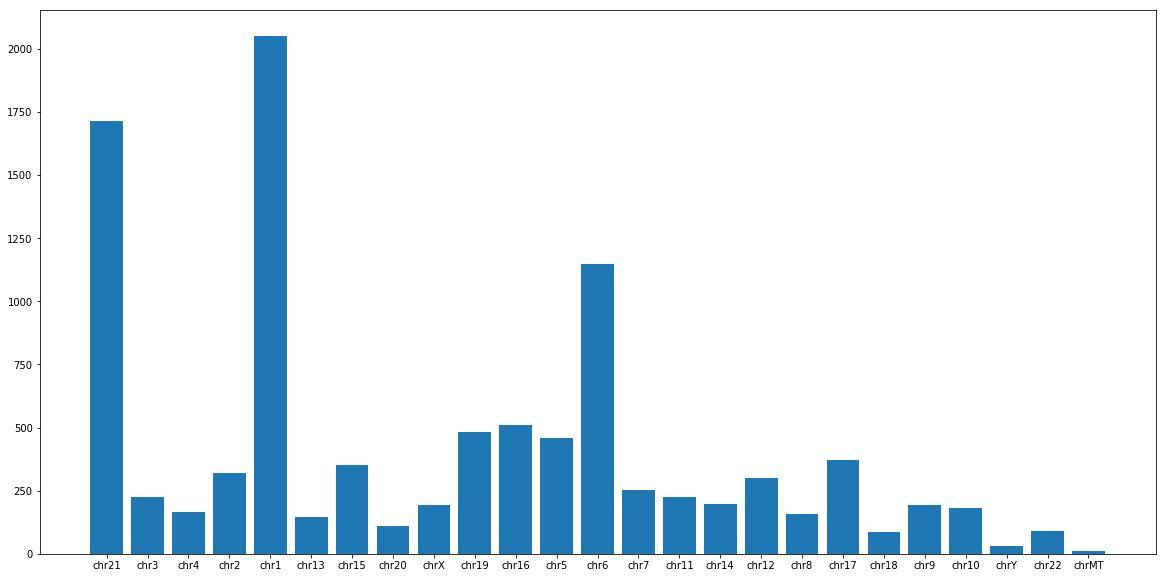

In [0]:
# create an object figure
plt.figure(figsize = (20, 10))
# draw the bar plot
plt.bar(x_scalar, chrom_alignments)
# assign labels to x-aixs
plt.xticks(x_scalar, chrom_names)
# show the plot here
plt.show()